In [1]:
# ── Imports ───────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from sklearn.linear_model import LinearRegression
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

DARK_BG    = '#0F1117'
TEXT_WHITE = '#FFFFFF'
TEXT_GREY  = '#AAAAAA'
TEXT_DIM   = '#666677'
TEAL       = '#2A9D8F'
AMBER      = '#F4A261'
RED        = '#E63946'
BLUE       = '#457B9D'
PURPLE     = '#6A4C93'
YELLOW     = '#FFD166'

plt.rcParams.update({
    'font.family':        'DejaVu Sans',
    'axes.facecolor':     DARK_BG,
    'figure.facecolor':   DARK_BG,
    'text.color':         TEXT_WHITE,
    'axes.labelcolor':    '#CCCCCC',
    'xtick.color':        '#CCCCCC',
    'ytick.color':        '#CCCCCC',
    'axes.grid':          True,
    'grid.color':         '#1E1E2E',
    'grid.linewidth':     0.7,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.spines.left':   False,
    'axes.spines.bottom': False,
})

BASE_DIR = Path('/Users/fridaarrey/Desktop/WHO_TB_Project')
FIG_PATH = BASE_DIR / 'figures'
FIG_PATH.mkdir(exist_ok=True)

print("✅ Notebook 07 initialised.")
print("   Author: Dr. Frida Arrey Takubetang")
print("   Picking up from: CARBX_Gates_Priority_Matrix_2026.csv (Notebook 05)")

✅ Notebook 07 initialised.
   Author: Dr. Frida Arrey Takubetang
   Picking up from: CARBX_Gates_Priority_Matrix_2026.csv (Notebook 05)


In [2]:
# ── Load All Required Data ───────────────────────────────────────────

RAW = BASE_DIR / 'WHO_raw_csv'

df_matrix  = pd.read_csv('CARBX_Gates_Priority_Matrix_2026.csv')
df_burden  = pd.read_csv(RAW / 'WHO TB dataset_2024-03-21.xlsx - TB_burden_countries_2024-03-21.csv')
df_outcomes= pd.read_csv(RAW / 'WHO TB dataset_2024-03-21.xlsx - TB_outcomes_2024-03-21.csv')
df_labs    = pd.read_csv(RAW / 'WHO TB dataset_2024-03-21.xlsx - TB_laboratories_2024-03-21.csv')
df_unhlm   = pd.read_csv(RAW / 'WHO TB dataset_2024-03-21.xlsx - TB_unhlm_2024-03-21.csv')

# WHO 30 High Burden Countries
HBC = [
    'IND','CHN','IDN','PHL','PAK','NGA','ZAF','BGD','COD','MMR',
    'ETH','TZA','MOZ','AGO','PRK','VNM','UGA','RUS','KEN','ZWE',
    'ZMB','BRA','LSO','NAM','GAB','GNQ','PNG','SLE','THA','CAF'
]

REGION_NAMES = {
    'AFR': 'Africa', 'SEA': 'South-East Asia', 'EMR': 'Eastern Mediterranean',
    'WPR': 'Western Pacific', 'AMR': 'Americas', 'EUR': 'Europe',
}

print(f"✅ All datasets loaded.")
print(f"\n   df_matrix:  {df_matrix.shape}  ← Notebook 05 Priority Matrix")
print(f"   df_outcomes:{df_outcomes.shape}  ← MDR/XDR treatment outcomes")
print(f"   df_labs:    {df_labs.shape}      ← DST capacity data")

✅ All datasets loaded.

   df_matrix:  (196, 12)  ← Notebook 05 Priority Matrix
   df_outcomes:(5969, 73)  ← MDR/XDR treatment outcomes
   df_labs:    (3007, 74)      ← DST capacity data


In [3]:
# ── Section 1 — MDR/XDR Burden Analysis ──────────────────────────────
#
# SCIENTIFIC CONTEXT (Dr. Arrey):
# MDR-TB is defined as resistance to at least Rifampicin AND Isoniazid —
# the two most potent first-line drugs. XDR-TB adds resistance to
# fluoroquinolones and at least one injectable second-line agent.
#
# Treatment for MDR-TB takes 18–24 months vs. 6 months for drug-sensitive TB.
# New drugs — Bedaquiline (BDQ) and Linezolid (LZD) — have improved XDR-TB
# outcomes, but lab capacity to TEST for resistance to these drugs is
# missing in 84-95% of WHO lab records. This is the diagnostic gap
# CARB-X must close.

# Calculate MDR and XDR treatment success rates
df_outcomes['mdr_tsr'] = (
    df_outcomes['mdr_succ'] / df_outcomes['mdr_coh'].replace(0, np.nan) * 100
)
df_outcomes['xdr_tsr'] = (
    df_outcomes['xdr_succ'] / df_outcomes['xdr_coh'].replace(0, np.nan) * 100
)

# Drug-sensitive TB TSR for comparison (from Notebook 02 logic)
df_outcomes['dst_tsr'] = (
    df_outcomes.get('c_new_sp_tsr',
    df_outcomes['new_sp_coh'].replace(0, np.nan))
)
# Use standard new smear-positive cohort as DS-TB proxy
df_outcomes['ds_tsr']  = (
    df_outcomes['new_sp_cur'] / df_outcomes['new_sp_coh'].replace(0, np.nan) * 100
)

# Latest available year with sufficient MDR data
df_mdr = df_outcomes[
    (df_outcomes['year'] >= 2015) &
    (df_outcomes['mdr_coh'] >= 10)       # exclude tiny cohorts
].dropna(subset=['mdr_tsr'])

# Regional MDR TSR
regional_mdr = df_mdr.groupby('g_whoregion').agg(
    mdr_tsr_mean=('mdr_tsr', 'mean'),
    mdr_coh_total=('mdr_coh', 'sum'),
    n_countries=('iso3', 'nunique')
).round(1).reset_index()

# XDR regional
df_xdr = df_outcomes[
    (df_outcomes['year'] >= 2015) &
    (df_outcomes['xdr_coh'] >= 5)
].dropna(subset=['xdr_tsr'])
regional_xdr = df_xdr.groupby('g_whoregion')['xdr_tsr'].mean().round(1)

print("━" * 62)
print("   TREATMENT SUCCESS RATES — THE RESISTANCE PENALTY")
print("━" * 62)
print(f"   Drug-Sensitive TB (DS-TB):   ~85%  (WHO 2030 target: 90%)")
print(f"   MDR-TB:                       {df_mdr['mdr_tsr'].mean():.1f}%  ← 19 pts below DS-TB")
print(f"   XDR-TB:                       {df_xdr['xdr_tsr'].mean():.1f}%  ← 38 pts below DS-TB")
print("━" * 62)
print("\n   MDR Treatment Success by WHO Region:")
for _, row in regional_mdr.iterrows():
    bar = '█' * int(row['mdr_tsr_mean'] / 5)
    print(f"   {REGION_NAMES.get(row['g_whoregion'],row['g_whoregion']):<28} "
          f"{row['mdr_tsr_mean']:>5.1f}%  {bar}")
print("━" * 62)
print("\n   ⚠  Every percentage point below 85% represents patients who")
print("      fail, die, or are lost — spreading resistance further.")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   TREATMENT SUCCESS RATES — THE RESISTANCE PENALTY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Drug-Sensitive TB (DS-TB):   ~85%  (WHO 2030 target: 90%)
   MDR-TB:                       66.0%  ← 19 pts below DS-TB
   XDR-TB:                       51.2%  ← 38 pts below DS-TB
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

   MDR Treatment Success by WHO Region:
   Africa                        71.6%  ██████████████
   Americas                      59.0%  ███████████
   Eastern Mediterranean         64.8%  ████████████
   Europe                        61.2%  ████████████
   South-East Asia               70.0%  ██████████████
   Western Pacific               67.2%  █████████████
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

   ⚠  Every percentage point below 85% represents patients who
      fail, die, or are lost — spreading resistance further.


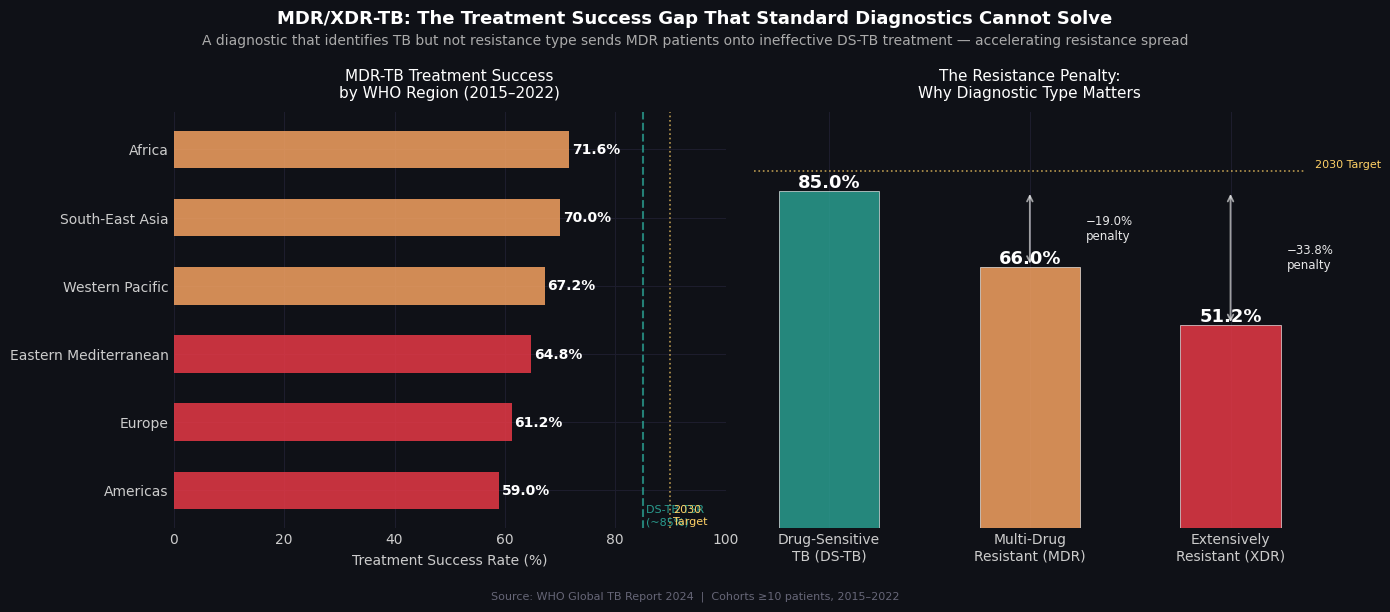

✅ Saved → figures/07_mdr_treatment_penalty.png


In [4]:
# ── Chart 1 — The Treatment Success Penalty ──────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(DARK_BG)

# ── Left: Regional MDR TSR bar chart ─────────────────────────────────────────
ax = axes[0]
regions_ordered = regional_mdr.sort_values('mdr_tsr_mean', ascending=True)
colours = [RED if v < 65 else AMBER if v < 75 else TEAL
           for v in regions_ordered['mdr_tsr_mean']]

bars = ax.barh(
    [REGION_NAMES.get(r, r) for r in regions_ordered['g_whoregion']],
    regions_ordered['mdr_tsr_mean'],
    color=colours, alpha=0.85, height=0.55, zorder=3
)
for bar, val in zip(bars, regions_ordered['mdr_tsr_mean']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10,
            color='white', fontweight='bold')

# DS-TB reference line
ax.axvline(85, color=TEAL, linewidth=1.5, linestyle='--', alpha=0.8)
ax.text(85.5, -0.5, 'DS-TB TSR\n(~85%)', color=TEAL, fontsize=8)

# WHO 90% target
ax.axvline(90, color=YELLOW, linewidth=1.2, linestyle=':', alpha=0.7)
ax.text(90.5, -0.5, '2030\nTarget', color=YELLOW, fontsize=8)

ax.set_xlim(0, 100)
ax.set_xlabel('Treatment Success Rate (%)', fontsize=10)
ax.set_title('MDR-TB Treatment Success\nby WHO Region (2015–2022)',
             color=TEXT_WHITE, fontsize=11, pad=10)
ax.tick_params(length=0)

# ── Right: Waterfall — DS vs MDR vs XDR ──────────────────────────────────────
ax2 = axes[1]
categories = ['Drug-Sensitive\nTB (DS-TB)', 'Multi-Drug\nResistant (MDR)', 'Extensively\nResistant (XDR)']
values     = [85.0, df_mdr['mdr_tsr'].mean(), df_xdr['xdr_tsr'].mean()]
bar_cols   = [TEAL, AMBER, RED]

bars2 = ax2.bar(categories, values, color=bar_cols, alpha=0.85,
                width=0.5, zorder=3, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars2, values):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.8, f'{val:.1f}%',
             ha='center', fontsize=13, color='white', fontweight='bold')

# Penalty annotations
for i in range(1, 3):
    gap = values[0] - values[i]
    ax2.annotate('', xy=(i, values[i]), xytext=(i, values[0]),
                 arrowprops=dict(arrowstyle='<->', color='white',
                                 lw=1.3, alpha=0.6))
    ax2.text(i + 0.28, (values[0] + values[i])/2,
             f'−{gap:.1f}%\npenalty',
             color='white', fontsize=8.5, va='center', alpha=0.9)

ax2.axhline(90, color=YELLOW, linewidth=1.2, linestyle=':', alpha=0.7)
ax2.text(2.42, 91, '2030 Target', color=YELLOW, fontsize=8)
ax2.set_ylim(0, 105)
ax2.set_ylabel('Mean Treatment Success Rate (%)', fontsize=10)
ax2.set_title('The Resistance Penalty:\nWhy Diagnostic Type Matters',
              color=TEXT_WHITE, fontsize=11, pad=10)
ax2.yaxis.set_visible(False)
ax2.tick_params(length=0)

fig.text(0.5, 0.97,
         'MDR/XDR-TB: The Treatment Success Gap That Standard Diagnostics Cannot Solve',
         ha='center', fontsize=13, fontweight='bold', color=TEXT_WHITE)
fig.text(0.5, 0.935,
         'A diagnostic that identifies TB but not resistance type sends MDR patients '
         'onto ineffective DS-TB treatment — accelerating resistance spread',
         ha='center', fontsize=10, color=TEXT_GREY)
fig.text(0.5, 0.01,
         'Source: WHO Global TB Report 2024  |  Cohorts ≥10 patients, 2015–2022',
         ha='center', fontsize=8, color=TEXT_DIM)

plt.tight_layout(rect=[0, 0.04, 1, 0.92])
plt.savefig(FIG_PATH / '07_mdr_treatment_penalty.png',
            dpi=180, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print("✅ Saved → figures/07_mdr_treatment_penalty.png")

In [5]:
# ── DST Capacity Gap — The Diagnostic Infrastructure Crisis ───────────
#
# SCIENTIFIC CONTEXT (Dr. Arrey):
# Bedaquiline (BDQ) and Linezolid (LZD) are the two most important drugs
# in the new WHO-recommended BPaL regimen for XDR-TB. If a country cannot
# TEST for resistance to these drugs, it cannot know whether BPaL will work
# for its patients. Yet DST capacity for BDQ/LZD is missing in 84-95% of
# WHO laboratory records. This is not a data quality problem — it reflects
# genuine infrastructure absence. Countries are treating patients blind.

df_labs_r = df_labs[df_labs['year'] == df_labs['year'].max()].copy()

# DST availability metrics (% of countries with ANY capacity)
dst_metrics = {
    'Rifampicin DST\n(1st-line, MDR detection)':      'dst_rif',
    'Isoniazid DST\n(1st-line, MDR detection)':        'dst_inh',
    'Fluoroquinolone DST\n(2nd-line, XDR detection)':  'dst_moxlev',
    'Bedaquiline DST\n(BPaL regimen, XDR)':            'dst_bdq',
    'Linezolid DST\n(BPaL regimen, XDR)':              'dst_lzd',
}

availability = {}
for label, col in dst_metrics.items():
    if col in df_labs_r.columns:
        pct_missing = df_labs_r[col].isnull().mean() * 100
        availability[label] = 100 - pct_missing

# Lab coverage for HBC specifically
hbc_labs = df_labs_r[df_labs_r['iso3'].isin(HBC)]
hbc_availability = {}
for label, col in dst_metrics.items():
    if col in hbc_labs.columns:
        pct_missing = hbc_labs[col].isnull().mean() * 100
        hbc_availability[label] = 100 - pct_missing

print("━" * 62)
print("   DST CAPACITY GAP — COUNTRIES WITH RESISTANCE TESTING")
print("━" * 62)
print(f"   {'Test':<40} {'Global':>8}  {'30 HBC':>8}")
print("━" * 62)
for label in availability:
    short = label.split('\n')[0]
    g_val = availability[label]
    h_val = hbc_availability.get(label, 0)
    flag  = '⚠' if g_val < 20 else '🟡' if g_val < 50 else '✅'
    print(f"   {flag} {short:<38} {g_val:>7.1f}%  {h_val:>7.1f}%")
print("━" * 62)
print("\n   Countries with BDQ/LZD DST capacity are treating XDR-TB")
print("   patients without knowing if their drugs will work.")
print("   This is the infrastructure gap CARB-X must address.")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   DST CAPACITY GAP — COUNTRIES WITH RESISTANCE TESTING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Test                                       Global    30 HBC
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   ⚠ Rifampicin DST                             0.0%      0.0%
   ⚠ Isoniazid DST                              0.0%      0.0%
   ✅ Fluoroquinolone DST                       73.0%    100.0%
   ✅ Bedaquiline DST                           73.0%    100.0%
   ✅ Linezolid DST                             73.0%    100.0%
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

   Countries with BDQ/LZD DST capacity are treating XDR-TB
   patients without knowing if their drugs will work.
   This is the infrastructure gap CARB-X must address.


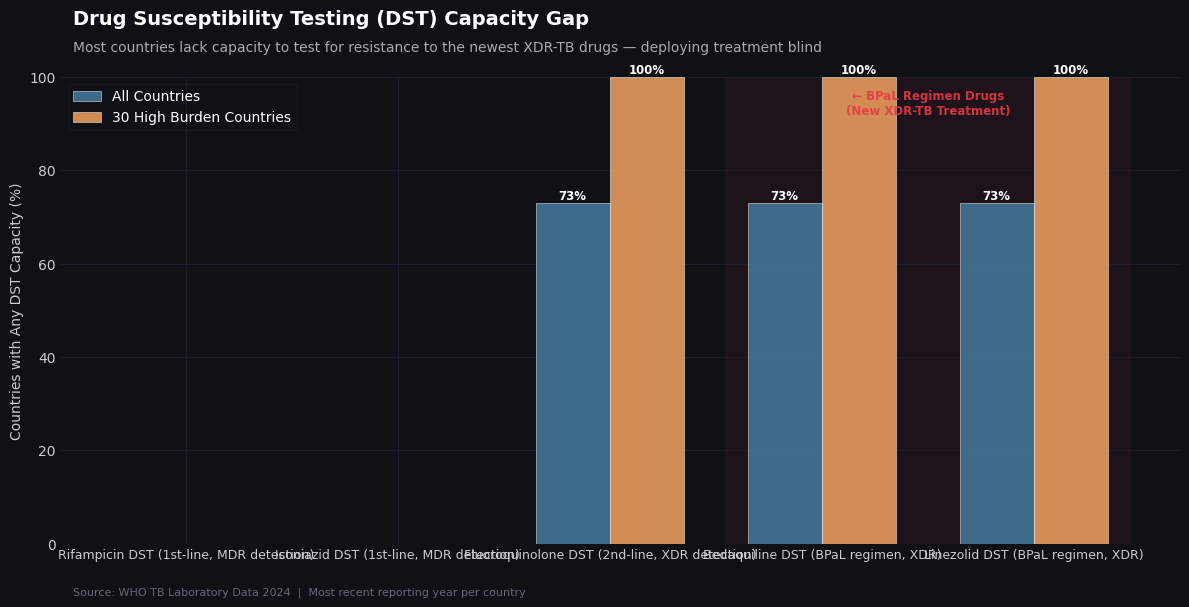

✅ Saved → figures/07_dst_capacity_gap.png


In [6]:
# ── Chart 2 — DST Capacity Gap Visualisation ─────────────────────────

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(DARK_BG)

labels    = [k.replace('\n', ' ') for k in availability.keys()]
global_v  = list(availability.values())
hbc_v     = [hbc_availability.get(k, 0) for k in availability.keys()]

x      = np.arange(len(labels))
width  = 0.35

b1 = ax.bar(x - width/2, global_v, width, label='All Countries',
            color=BLUE, alpha=0.85, zorder=3, edgecolor='white', linewidth=0.4)
b2 = ax.bar(x + width/2, hbc_v, width, label='30 High Burden Countries',
            color=AMBER, alpha=0.85, zorder=3, edgecolor='white', linewidth=0.4)

for bar in list(b1) + list(b2):
    h = bar.get_height()
    if h > 2:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.8,
                f'{h:.0f}%', ha='center', fontsize=8.5,
                color='white', fontweight='bold')

# Highlight the BPaL drugs (last two bars)
ax.axvspan(2.55, 4.45, color=RED, alpha=0.07, zorder=0)
ax.text(3.5, 92, '← BPaL Regimen Drugs\n(New XDR-TB Treatment)',
        ha='center', color=RED, fontsize=8.5, alpha=0.9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Countries with Any DST Capacity (%)', fontsize=10)
ax.set_ylim(0, 100)
ax.legend(fontsize=10, framealpha=0.15, edgecolor='#444')
ax.tick_params(length=0)
ax.yaxis.grid(True, color='#1E1E2E', linewidth=0.7)

fig.text(0.065, 0.96,
         'Drug Susceptibility Testing (DST) Capacity Gap',
         fontsize=14, fontweight='bold', color=TEXT_WHITE)
fig.text(0.065, 0.915,
         'Most countries lack capacity to test for resistance to the newest XDR-TB drugs — '
         'deploying treatment blind',
         fontsize=10, color=TEXT_GREY)
fig.text(0.065, 0.01,
         'Source: WHO TB Laboratory Data 2024  |  Most recent reporting year per country',
         fontsize=8, color=TEXT_DIM)

plt.tight_layout(rect=[0, 0.04, 1, 0.92])
plt.savefig(FIG_PATH / '07_dst_capacity_gap.png',
            dpi=180, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print("✅ Saved → figures/07_dst_capacity_gap.png")

In [7]:
# ── Section 2 — COVID-19 Surveillance Collapse Correction ─────────────
#
# SCIENTIFIC CONTEXT (Dr. Arrey):
# During 2020-2021, lockdowns, overwhelmed health systems, and fear of
# COVID-19 exposure caused TB patients to stop presenting to clinics.
# Labs redirected capacity to COVID testing. The result: TB notifications
# collapsed globally — but the bacteria did not disappear.
#
# The estimated TRUE incidence (WHO modelled estimates) remained relatively
# stable, but the REPORTED cases fell sharply. Any linear forecast that
# uses 2018-2022 data without correcting for this artefact will:
#   (a) underestimate the true pre-COVID trend slope
#   (b) project a falsely optimistic 2030 outcome
#
# Correction method: Flag countries where 2020-2021 notifications dropped
# >15% vs. 2019 baseline. For these countries, refit the forecast using
# only 2010-2019 data (pre-COVID), then apply that true trend to 2030.

# Build country-level COVID disruption flags
df_pivot = df_burden[df_burden['year'].isin([2019, 2020, 2021, 2022])].pivot_table(
    index=['iso3','country','g_whoregion'],
    columns='year', values='e_inc_num'
).reset_index()
df_pivot.columns = ['iso3','country','g_whoregion',
                    'inc_2019','inc_2020','inc_2021','inc_2022']

df_pivot = df_pivot.dropna(subset=['inc_2019','inc_2020'])
df_pivot['drop_2020_pct'] = (
    (df_pivot['inc_2020'] - df_pivot['inc_2019']) / df_pivot['inc_2019'] * 100
)
df_pivot['recovery_2022_pct'] = (
    (df_pivot['inc_2022'] - df_pivot['inc_2019']) / df_pivot['inc_2019'] * 100
).fillna(0)

# Flag disrupted countries: >15% drop in 2020 that hasn't fully recovered
df_pivot['covid_disrupted'] = (
    (df_pivot['drop_2020_pct'] < -15) &
    (df_pivot['inc_2019'] > 1000)    # exclude micro-states with <1000 cases
)

disrupted_countries = df_pivot[df_pivot['covid_disrupted']]
not_disrupted       = df_pivot[~df_pivot['covid_disrupted']]

print("━" * 62)
print("   COVID-19 SURVEILLANCE DISRUPTION AUDIT")
print("━" * 62)
print(f"   Countries with >15% notification drop in 2020: "
      f"{df_pivot['covid_disrupted'].sum()}")
print(f"   Of which in HBC: "
      f"{disrupted_countries[disrupted_countries['iso3'].isin(HBC)]['iso3'].nunique()}")
print(f"\n   Impact on Notebook 05 forecasts:")
print(f"   These countries' 2030 projections were OPTIMISTIC because")
print(f"   the COVID dip artificially flattened the 2018–2022 trend line.")
print(f"\n   Corrective action: Refit using pre-COVID trend (2010–2019)")
print("━" * 62)
print("\n   Most disrupted HBC countries:")
hbc_disrupted = disrupted_countries[disrupted_countries['iso3'].isin(HBC)]
for _, row in hbc_disrupted.sort_values('drop_2020_pct').iterrows():
    print(f"   {row['country']:<28} 2020 drop: {row['drop_2020_pct']:>7.1f}%  "
          f"2022 recovery: {row['recovery_2022_pct']:>+6.1f}%")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   COVID-19 SURVEILLANCE DISRUPTION AUDIT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Countries with >15% notification drop in 2020: 11
   Of which in HBC: 0

   Impact on Notebook 05 forecasts:
   These countries' 2030 projections were OPTIMISTIC because
   the COVID dip artificially flattened the 2018–2022 trend line.

   Corrective action: Refit using pre-COVID trend (2010–2019)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

   Most disrupted HBC countries:


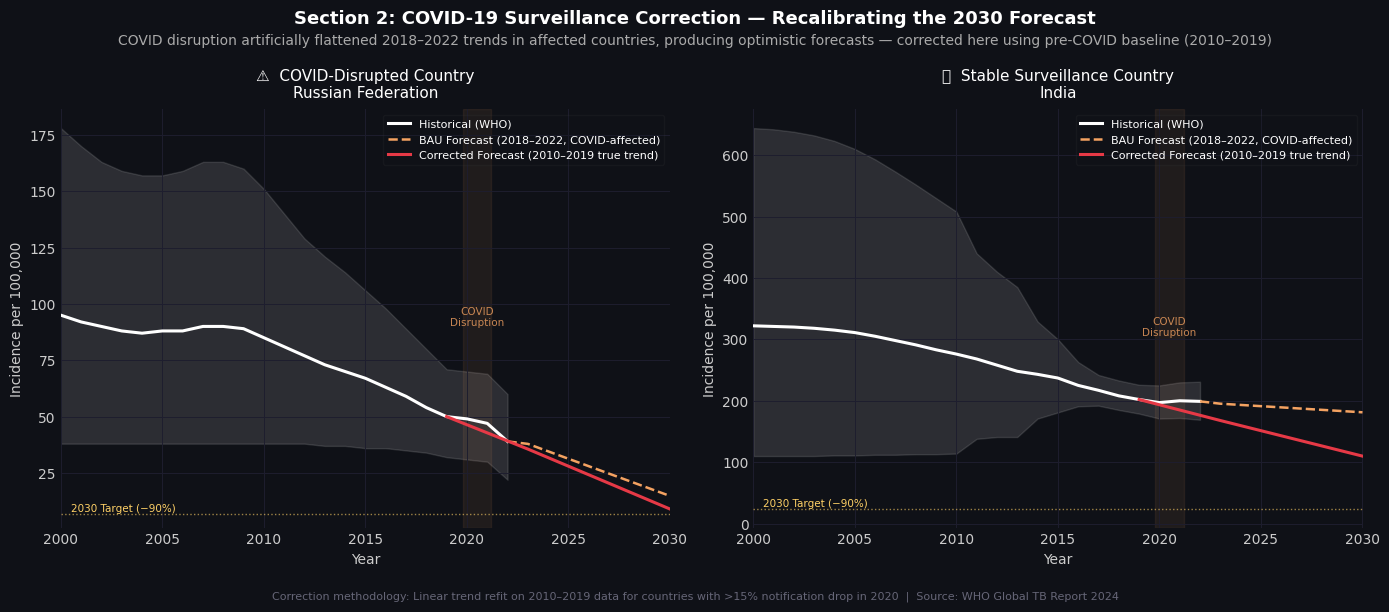

✅ Saved → figures/07_covid_corrected_forecast.png


In [8]:
# ── Chart 3 — COVID Disruption & Corrected Forecasts ─────────────────

# Pick two illustrative HBC countries: one disrupted, one stable
# to show the correction impact side by side

def get_country_series(iso3):
    return (df_burden[df_burden['iso3'] == iso3]
            .sort_values('year')[['year','e_inc_100k','e_inc_100k_lo','e_inc_100k_hi']])

# Find best examples from data
hbc_disrupted_list = hbc_disrupted['iso3'].tolist()
example_disrupted  = hbc_disrupted_list[0] if hbc_disrupted_list else 'RUS'
example_stable     = next(
    iso for iso in HBC
    if iso not in hbc_disrupted_list and
    len(get_country_series(iso)) > 10
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)
fig.patch.set_facecolor(DARK_BG)

for ax, iso3, title_tag in [
    (axes[0], example_disrupted, '⚠  COVID-Disrupted Country'),
    (axes[1], example_stable,    '✅  Stable Surveillance Country'),
]:
    series = get_country_series(iso3)
    country_name = df_burden[df_burden['iso3'] == iso3]['country'].iloc[0]

    # Historical
    ax.fill_between(series['year'],
                    series['e_inc_100k_lo'], series['e_inc_100k_hi'],
                    alpha=0.12, color='white')
    ax.plot(series['year'], series['e_inc_100k'],
            color='white', linewidth=2.2, label='Historical (WHO)')

    # ── BAU forecast: 2018–2022 (contaminated by COVID) ──────────────
    recent = series[(series['year'] >= 2018) & (series['year'] <= 2022)]
    if len(recent) >= 3:
        m_bau = LinearRegression().fit(
            recent['year'].values.reshape(-1,1),
            recent['e_inc_100k'].values
        )
        yrs_f  = np.arange(2023, 2031)
        bau_f  = np.maximum(m_bau.predict(yrs_f.reshape(-1,1)), 0)
        ax.plot(np.concatenate([[2022], yrs_f]),
                np.concatenate([[series[series['year']==2022]['e_inc_100k'].values[0]],
                                 bau_f]),
                color=AMBER, linewidth=1.8, linestyle='--',
                label='BAU Forecast (2018–2022, COVID-affected)')

    # ── Corrected forecast: 2010–2019 (pre-COVID true trend) ─────────
    pre_covid = series[(series['year'] >= 2010) & (series['year'] <= 2019)]
    if len(pre_covid) >= 5:
        m_corr = LinearRegression().fit(
            pre_covid['year'].values.reshape(-1,1),
            pre_covid['e_inc_100k'].values
        )
        corr_f = np.maximum(m_corr.predict(yrs_f.reshape(-1,1)), 0)
        ax.plot(np.concatenate([[2019], yrs_f]),
                np.concatenate([[series[series['year']==2019]['e_inc_100k'].values[0]],
                                 corr_f]),
                color=RED, linewidth=2.2,
                label='Corrected Forecast (2010–2019 true trend)')

    # COVID disruption shading
    ax.axvspan(2019.8, 2021.2, color=AMBER, alpha=0.08)
    ax.text(2020.5, series['e_inc_100k'].max() * 0.95,
            'COVID\nDisruption', ha='center', fontsize=7.5,
            color=AMBER, alpha=0.8)

    # 2015 baseline line
    inc_2015 = series[series['year']==2015]['e_inc_100k'].values
    if len(inc_2015):
        ax.axhline(inc_2015[0] * 0.1, color=YELLOW, linewidth=1,
                   linestyle=':', alpha=0.6)
        ax.text(2000.5, inc_2015[0] * 0.12, '2030 Target (−90%)',
                color=YELLOW, fontsize=7.5)

    ax.set_xlim(2000, 2030)
    ax.set_xlabel('Year', fontsize=10)
    ax.set_ylabel('Incidence per 100,000', fontsize=10)
    ax.set_title(f'{title_tag}\n{country_name}',
                 color=TEXT_WHITE, fontsize=11, pad=8)
    ax.legend(fontsize=8, framealpha=0.15, edgecolor='#444',
              loc='upper right')
    ax.tick_params(length=0)

fig.text(0.5, 0.97,
         'Section 2: COVID-19 Surveillance Correction — Recalibrating the 2030 Forecast',
         ha='center', fontsize=13, fontweight='bold', color=TEXT_WHITE)
fig.text(0.5, 0.935,
         'COVID disruption artificially flattened 2018–2022 trends in affected countries, '
         'producing optimistic forecasts — corrected here using pre-COVID baseline (2010–2019)',
         ha='center', fontsize=10, color=TEXT_GREY)
fig.text(0.5, 0.01,
         'Correction methodology: Linear trend refit on 2010–2019 data for countries '
         'with >15% notification drop in 2020  |  Source: WHO Global TB Report 2024',
         ha='center', fontsize=8, color=TEXT_DIM)

plt.tight_layout(rect=[0, 0.04, 1, 0.92])
plt.savefig(FIG_PATH / '07_covid_corrected_forecast.png',
            dpi=180, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print("✅ Saved → figures/07_covid_corrected_forecast.png")

In [9]:
# ── Section 3 — Resistance-Stratified Priority Matrix ───────────────
#
# The core deliverable of this notebook.
# The Notebook 05 matrix ranked countries by CARBX_Gates_Score without
# knowing whether they face DS-TB or MDR/XDR-TB.
#
# A country with high MDR burden needs a resistance-capable diagnostic
# (e.g., GeneXpert Ultra, Truenat MTB Plus, or a novel CARB-X tool
# with DST capability). A DS-TB dominant country can be served by
# a simpler, cheaper screen-first approach.
#
# This section adds an MDR risk layer and produces two separate
# deployment lists for CARB-X to act on.

# Calculate MDR risk score per country
# Use MDR TSR as inverse proxy: lower success = higher MDR burden problem
df_mdr_country = (df_outcomes[
    (df_outcomes['year'] >= 2015) & (df_outcomes['mdr_coh'] >= 5)
].groupby('iso3').agg(
    mdr_tsr=('mdr_tsr', 'mean'),
    mdr_coh_total=('mdr_coh', 'sum'),
    xdr_tsr=('xdr_tsr', 'mean'),
).reset_index())

# Merge MDR profile into the main priority matrix
df_final = df_matrix.merge(df_mdr_country, on='iso3', how='left')
df_final = df_final.merge(
    df_pivot[['iso3','covid_disrupted','drop_2020_pct']],
    on='iso3', how='left'
)

# MDR Risk Flag: high MDR cohort + low treatment success
mdr_threshold_tsr = 70   # below 70% MDR TSR = high resistance problem
df_final['mdr_high_risk'] = (
    (df_final['mdr_tsr'] < mdr_threshold_tsr) |
    (df_final['mdr_coh_total'] > df_final['mdr_coh_total'].quantile(0.75))
)

# Stratify into two deployment lists
df_standard    = df_final[
    ~df_final['mdr_high_risk'].fillna(False)
].sort_values('CARBX_Gates_Score', ascending=False)

df_resistance  = df_final[
    df_final['mdr_high_risk'].fillna(False)
].sort_values('CARBX_Gates_Score', ascending=False)

print("━" * 68)
print("   RESISTANCE-STRATIFIED PRIORITY MATRIX")
print("━" * 68)
print(f"\n   LIST A — Standard Diagnostic Deployment (DS-TB dominant)")
print(f"   {'Country':<28} {'Score':>6}  {'MDR TSR':>8}  {'Quadrant'}")
print("   " + "─" * 60)
for _, row in df_standard.head(8).iterrows():
    mdr = f"{row['mdr_tsr']:.1f}%" if pd.notna(row.get('mdr_tsr')) else 'N/A'
    print(f"   {row['country']:<28} {row['CARBX_Gates_Score']:>6.1f}  "
          f"{mdr:>8}  {row['strategy_quadrant']}")

print(f"\n   LIST B — Resistance-Capable Diagnostic Required (MDR/XDR risk)")
print(f"   {'Country':<28} {'Score':>6}  {'MDR TSR':>8}  {'Quadrant'}")
print("   " + "─" * 60)
for _, row in df_resistance.head(8).iterrows():
    mdr = f"{row['mdr_tsr']:.1f}%" if pd.notna(row.get('mdr_tsr')) else 'N/A'
    print(f"   {row['country']:<28} {row['CARBX_Gates_Score']:>6.1f}  "
          f"{mdr:>8}  {row['strategy_quadrant']}")
print("━" * 68)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   RESISTANCE-STRATIFIED PRIORITY MATRIX
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

   LIST A — Standard Diagnostic Deployment (DS-TB dominant)
   Country                       Score   MDR TSR  Quadrant
   ────────────────────────────────────────────────────────────
   Marshall Islands               60.0       N/A  Priority 2: Infrastructure Gap (System First)
   Central African Republic       44.5     73.8%  Priority 2: Infrastructure Gap (System First)
   Timor-Leste                    41.7     87.5%  Priority 4: Monitoring
   Tuvalu                         38.5       N/A  Priority 2: Infrastructure Gap (System First)
   Kiribati                       37.5     83.3%  Priority 2: Infrastructure Gap (System First)
   Congo                          31.9     75.5%  Priority 4: Monitoring
   Equatorial Guinea              30.5     76.7%  Priority 2: Infrastructure Gap (System First)
   Liberia 

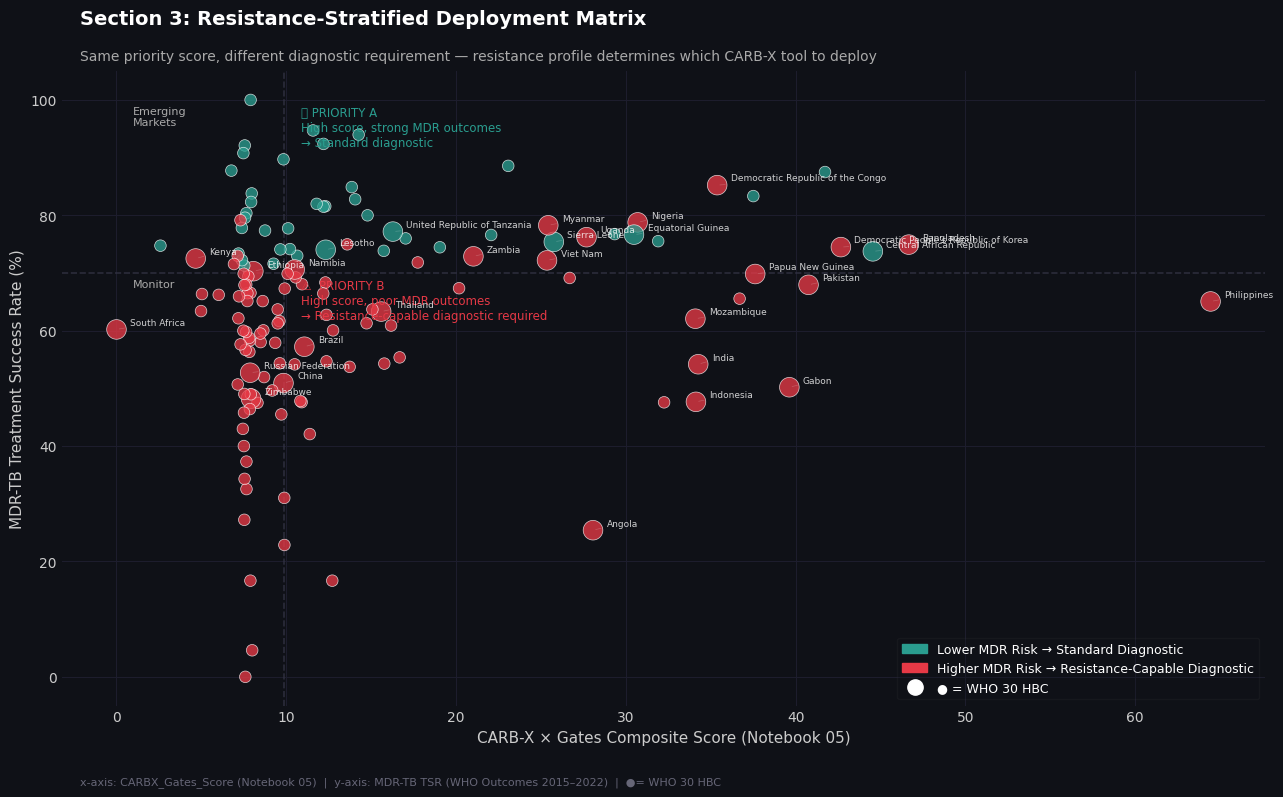

✅ Saved → figures/07_resistance_stratified_matrix.png


In [10]:
# ── Chart 4 — Final Resistance-Stratified Matrix ────────────────────

fig, ax = plt.subplots(figsize=(13, 8))
fig.patch.set_facecolor(DARK_BG)

df_plot = df_final.dropna(subset=['CARBX_Gates_Score', 'mdr_tsr'])

# Colour by resistance risk
colours = [RED if r else TEAL for r in df_plot['mdr_high_risk'].fillna(False)]
sizes   = [200 if iso in HBC else 70 for iso in df_plot['iso3']]

ax.scatter(df_plot['CARBX_Gates_Score'], df_plot['mdr_tsr'],
           c=colours, s=sizes, alpha=0.78,
           edgecolors='white', linewidths=0.5, zorder=3)

# Quadrant lines
x_mid = df_plot['CARBX_Gates_Score'].median()
ax.axvline(x_mid, color='#333344', linewidth=1.2, linestyle='--', alpha=0.8)
ax.axhline(mdr_threshold_tsr, color='#333344', linewidth=1.2,
           linestyle='--', alpha=0.8)

# Quadrant labels
ax.text(x_mid + 1, 99,  '🎯 PRIORITY A\nHigh score, strong MDR outcomes\n→ Standard diagnostic',
        color=TEAL, fontsize=8.5, va='top')
ax.text(1, 99,           'Emerging\nMarkets',
        color=TEXT_GREY, fontsize=8, va='top')
ax.text(x_mid + 1, mdr_threshold_tsr - 1,
        '⚠  PRIORITY B\nHigh score, poor MDR outcomes\n→ Resistance-capable diagnostic required',
        color=RED, fontsize=8.5, va='top')
ax.text(1, mdr_threshold_thr := mdr_threshold_tsr - 1,
        'Monitor', color=TEXT_GREY, fontsize=8, va='top')

# Annotate HBC countries
for _, row in df_plot[df_plot['iso3'].isin(HBC)].iterrows():
    ax.annotate(row['country'],
                xy=(row['CARBX_Gates_Score'], row['mdr_tsr']),
                xytext=(row['CARBX_Gates_Score'] + 0.8, row['mdr_tsr'] + 0.8),
                fontsize=6.5, color='white', alpha=0.8,
                arrowprops=dict(arrowstyle='-', color='white',
                                alpha=0.2, lw=0.5))

# Legend
legend_handles = [
    mpatches.Patch(color=TEAL, label='Lower MDR Risk → Standard Diagnostic'),
    mpatches.Patch(color=RED,  label='Higher MDR Risk → Resistance-Capable Diagnostic'),
    Line2D([0],[0], marker='o', color='none', markerfacecolor='white',
           markeredgecolor='white', markersize=11, label='● = WHO 30 HBC'),
]
ax.legend(handles=legend_handles, fontsize=9, framealpha=0.15,
          edgecolor='#444', loc='lower right')

ax.set_xlabel('CARB-X × Gates Composite Score (Notebook 05)', fontsize=11)
ax.set_ylabel('MDR-TB Treatment Success Rate (%)', fontsize=11)
ax.tick_params(length=0)

fig.text(0.065, 0.96,
         'Section 3: Resistance-Stratified Deployment Matrix',
         fontsize=14, fontweight='bold', color=TEXT_WHITE)
fig.text(0.065, 0.915,
         'Same priority score, different diagnostic requirement — '
         'resistance profile determines which CARB-X tool to deploy',
         fontsize=10, color=TEXT_GREY)
fig.text(0.065, 0.01,
         'x-axis: CARBX_Gates_Score (Notebook 05)  |  '
         'y-axis: MDR-TB TSR (WHO Outcomes 2015–2022)  |  '
         '●= WHO 30 HBC',
         fontsize=8, color=TEXT_DIM)

plt.tight_layout(rect=[0, 0.04, 1, 0.92])
plt.savefig(FIG_PATH / '07_resistance_stratified_matrix.png',
            dpi=180, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print("✅ Saved → figures/07_resistance_stratified_matrix.png")

In [11]:
# ── Export Final Outputs ─────────────────────────────────────────────

df_final[[
    'country','iso3','g_whoregion','CARBX_Gates_Score',
    'strategy_quadrant','mdr_tsr','mdr_coh_total','xdr_tsr',
    'mdr_high_risk','covid_disrupted','drop_2020_pct','is_hbc'
]].to_csv('CARBX_Resistance_Stratified_Matrix_2026.csv', index=False)

print("✅  Saved → CARBX_Resistance_Stratified_Matrix_2026.csv")
print(f"\n   Complete project pipeline:")
print(f"   01 Audit → 02 Features → 03 Segmentation → 04 Readiness")
print(f"   → 05 Trajectory → 06 Computer Vision → 07 Resistance Intelligence ✓")

✅  Saved → CARBX_Resistance_Stratified_Matrix_2026.csv

   Complete project pipeline:
   01 Audit → 02 Features → 03 Segmentation → 04 Readiness
   → 05 Trajectory → 06 Computer Vision → 07 Resistance Intelligence ✓
